# Phase 1: Hindi HTR — Data Exploration & Baseline

**This notebook covers:**
1. Load parquet files (train/val/test)
2. Inspect schema & sample data
3. Visualize handwritten word images
4. Analyze image dimensions
5. Character & label analysis (vocabulary, Unicode)
6. EasyOCR baseline evaluation
7. Summary report

-rw-r--r-- 1 root root 647144 May  1 10:33 /tmp/NotoSansDevanagari.ttf


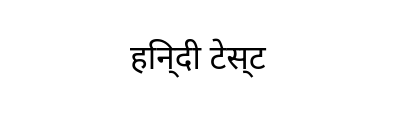

Font loaded successfully!


In [12]:
!pip install -q easyocr editdistance
# Download Noto Sans Devanagari font directly
!wget -q https://github.com/google/fonts/raw/main/ofl/notosansdevanagari/NotoSansDevanagari%5Bwdth%2Cwght%5D.ttf -O /tmp/NotoSansDevanagari.ttf
!ls -la /tmp/NotoSansDevanagari.ttf

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# Register the font manually
fm.fontManager.addfont('/tmp/NotoSansDevanagari.ttf')
plt.rcParams['font.family'] = 'Noto Sans Devanagari'
plt.rcParams['figure.dpi'] = 120

# Quick test
fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, 'हिन्दी टेस्ट', fontsize=20, ha='center', va='center')
ax.axis('off')
plt.show()
print('Font loaded successfully!')

In [13]:
import os, json, unicodedata
from collections import Counter
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

RESULTS = Path('results')
RESULTS.mkdir(exist_ok=True)
print('Setup complete')

Setup complete


## 1. Load Dataset

In [14]:
BASE = '/kaggle/input/datasets/nehamalik10/hindi-ocr-dataset'

# Train: 3 parquet shards
train_df = pd.concat([
    pd.read_parquet(os.path.join(BASE, 'train data 1.parquet')),
    pd.read_parquet(os.path.join(BASE, 'train data 2.parquet')),
    pd.read_parquet(os.path.join(BASE, 'train data 3.parquet')),
], ignore_index=True)

val_df   = pd.read_parquet(os.path.join(BASE, 'val data.parquet'))
test_df  = pd.read_parquet(os.path.join(BASE, 'test data.parquet'))

print(f'Train: {len(train_df):,} samples')
print(f'Val:   {len(val_df):,} samples')
print(f'Test:  {len(test_df):,} samples')
print(f'Total: {len(train_df)+len(val_df)+len(test_df):,} samples')

Train: 69,853 samples
Val:   12,708 samples
Test:  12,869 samples
Total: 95,430 samples


In [4]:
# Inspect schema
print('--- Columns ---')
print(train_df.columns.tolist())
print()
print('--- Dtypes ---')
print(train_df.dtypes)
print()
print('--- First 3 rows (non-image cols) ---')
non_img_cols = [c for c in train_df.columns if train_df[c].dtype != object or train_df[c].iloc[0].__class__.__name__ not in ('dict','bytes')]
train_df[non_img_cols].head(3)

--- Columns ---
['image', 'text']

--- Dtypes ---
image    object
text     object
dtype: object

--- First 3 rows (non-image cols) ---


,text
0,केंद्रों
1,फ़त्तू
2,सैटल


In [15]:
# Detect image & label columns automatically
sample_row = train_df.iloc[0]
print('--- Row 0 field inspection ---')
IMG_COL = None
LABEL_COL = None

for col in train_df.columns:
    val = sample_row[col]
    dtype_str = type(val).__name__
    
    # Check for image
    if isinstance(val, dict) and 'bytes' in val:
        IMG_COL = col
        print(f"  {col}: dict with 'bytes' key -> IMAGE column")
    elif isinstance(val, bytes):
        IMG_COL = col
        print(f"  {col}: raw bytes -> IMAGE column")
    elif isinstance(val, Image.Image):
        IMG_COL = col
        print(f"  {col}: PIL Image -> IMAGE column")
    # Check for label
    elif isinstance(val, str):
        LABEL_COL = col
        print(f"  {col}: str = {repr(val[:60])} -> LABEL column")
    else:
        print(f"  {col}: {dtype_str} = {repr(val)}")

# Fallback detection if auto-detect missed
if IMG_COL is None:
    for candidate in ['image', 'img', 'pixel_values', 'Image']:
        if candidate in train_df.columns:
            IMG_COL = candidate
            break

if LABEL_COL is None:
    for candidate in ['word', 'text', 'label', 'Word', 'Text', 'Label']:
        if candidate in train_df.columns:
            LABEL_COL = candidate
            break

print(f'\n=> Image column:  {IMG_COL}')
print(f'=> Label column:  {LABEL_COL}')
assert IMG_COL is not None, 'Could not detect image column! Check columns above.'
assert LABEL_COL is not None, 'Could not detect label column! Check columns above.'

--- Row 0 field inspection ---
  image: dict with 'bytes' key -> IMAGE column
  text: str = 'केंद्रों' -> LABEL column

=> Image column:  image
=> Label column:  text


In [16]:
# Helper: extract PIL image from a row
def row_to_image(row):
    """Convert a dataframe row's image field to a PIL Image."""
    val = row[IMG_COL]
    if isinstance(val, Image.Image):
        return val
    if isinstance(val, dict) and 'bytes' in val:
        return Image.open(BytesIO(val['bytes']))
    if isinstance(val, bytes):
        return Image.open(BytesIO(val))
    # If it's a path string
    if isinstance(val, str) and os.path.exists(val):
        return Image.open(val)
    raise ValueError(f'Cannot parse image from type {type(val)}')

# Quick test
test_img = row_to_image(train_df.iloc[0])
print(f'Test image: {test_img.size} mode={test_img.mode}')
print(f'Test label: {train_df.iloc[0][LABEL_COL]}')

Test image: (587, 293) mode=RGB
Test label: केंद्रों


## 2. Visualize Samples

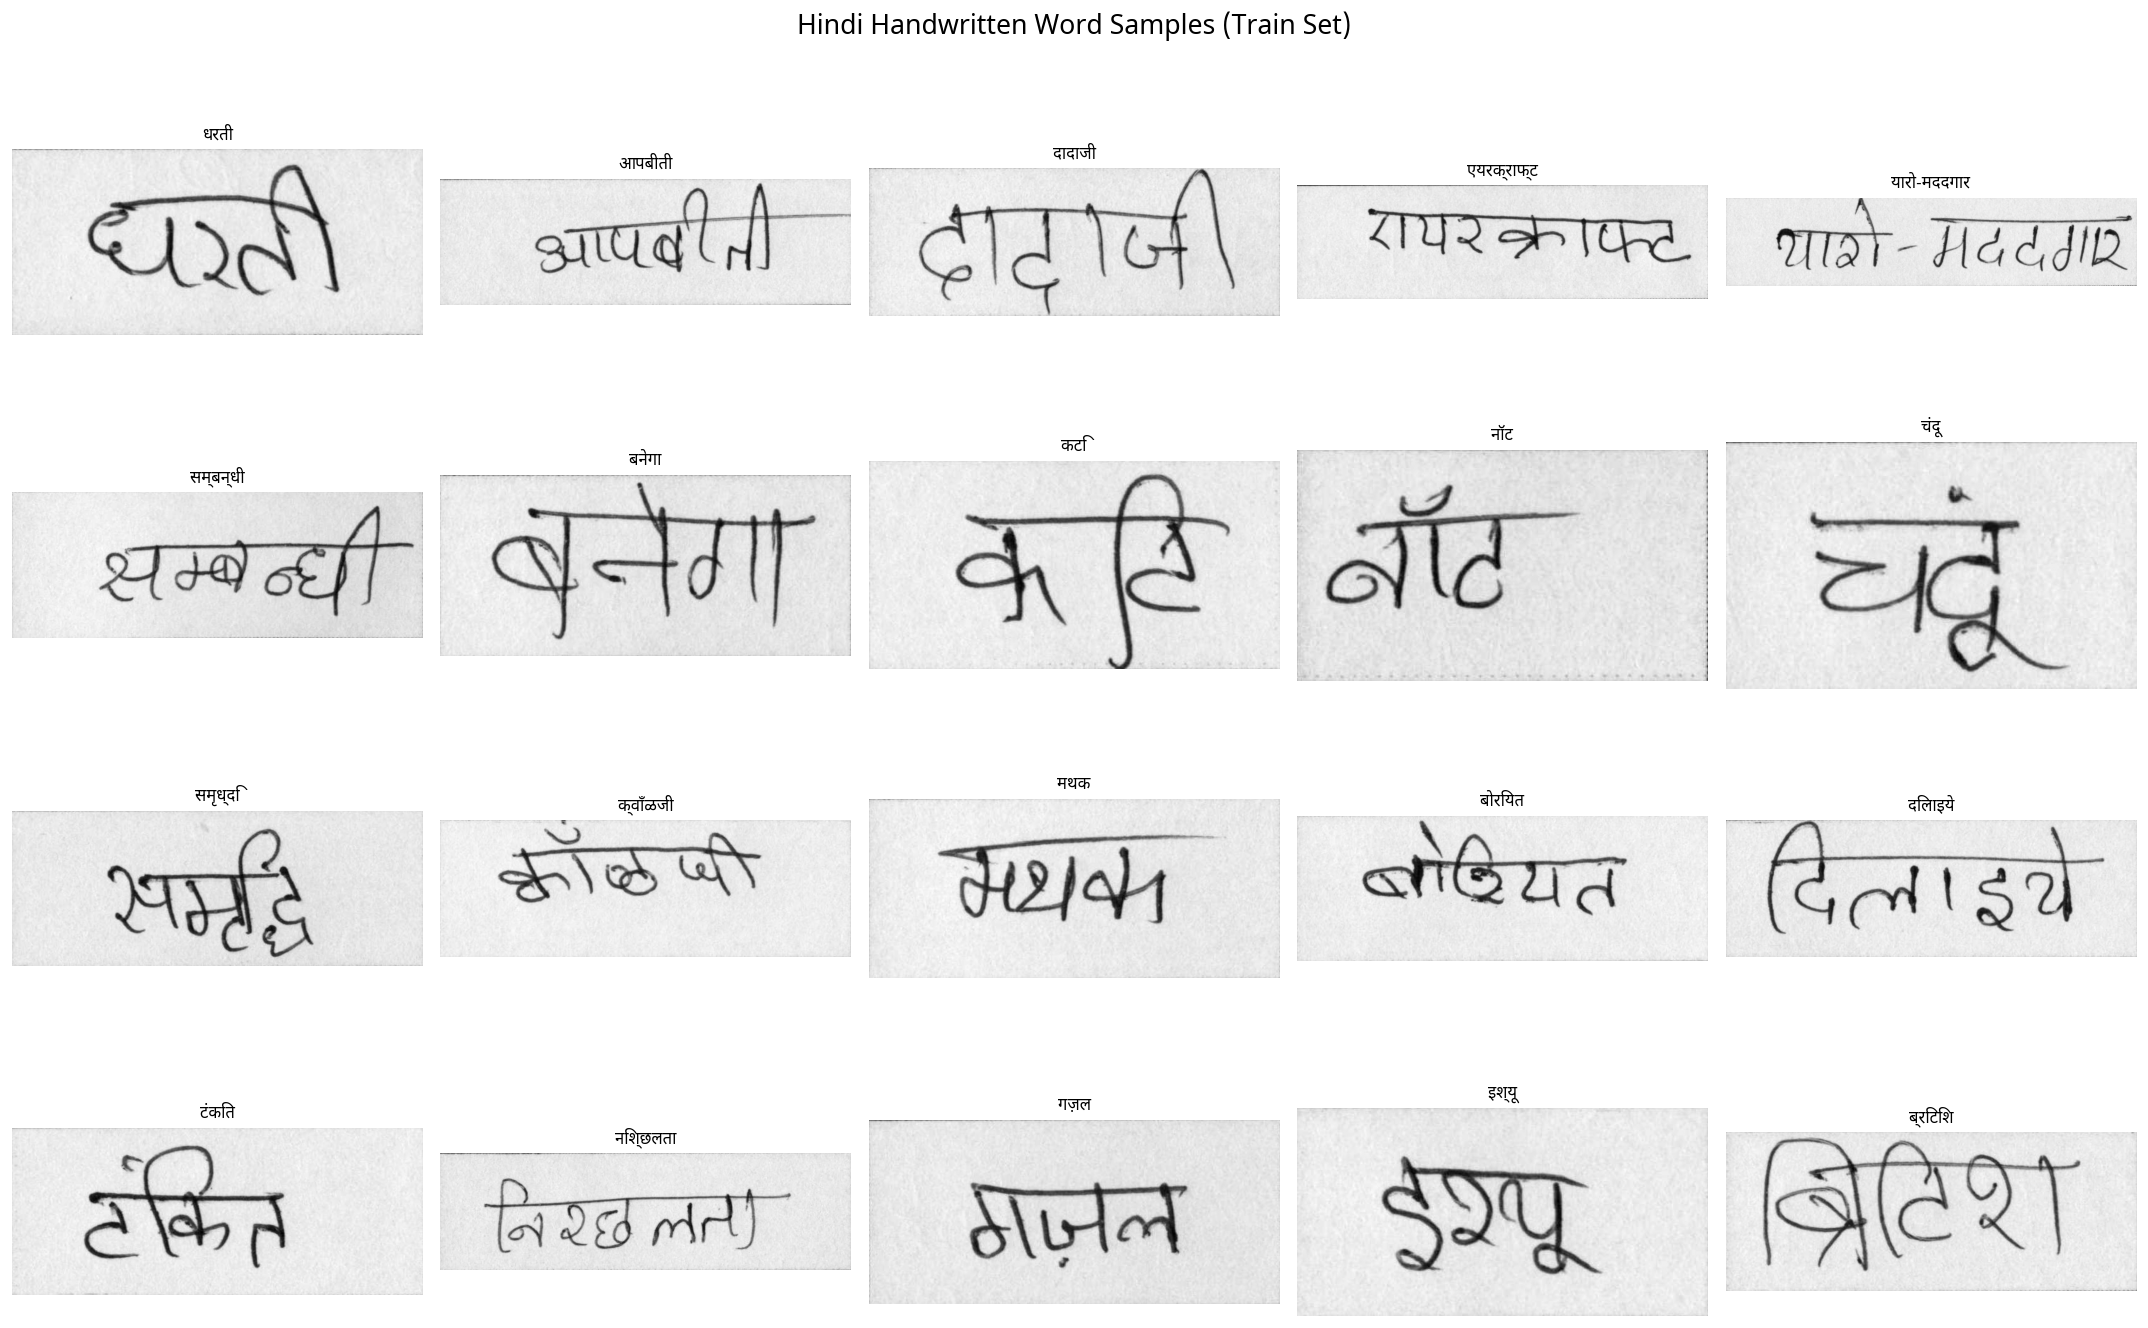

In [17]:
np.random.seed(42)
indices = np.random.choice(len(train_df), 20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
fig.suptitle('Hindi Handwritten Word Samples (Train Set)', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    row = train_df.iloc[indices[i]]
    try:
        img = row_to_image(row)
        ax.imshow(np.array(img.convert('L')), cmap='gray')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center', fontsize=7)
    ax.set_title(str(row[LABEL_COL]), fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Image Dimension Analysis

In [18]:
np.random.seed(42)
sample_idx = np.random.choice(len(train_df), min(1000, len(train_df)), replace=False)

widths, heights, means = [], [], []
for i in sample_idx:
    try:
        img = row_to_image(train_df.iloc[i])
        w, h = img.size
        widths.append(w)
        heights.append(h)
        means.append(np.array(img.convert('L')).mean())
    except:
        pass

print(f'Analyzed {len(widths)} images')
print(f'Width  — min:{min(widths):>5}  max:{max(widths):>5}  mean:{np.mean(widths):>7.1f}  median:{np.median(widths):>6.0f}')
print(f'Height — min:{min(heights):>5}  max:{max(heights):>5}  mean:{np.mean(heights):>7.1f}  median:{np.median(heights):>6.0f}')
print(f'Pixel mean: {np.mean(means):.1f} / 255')

Analyzed 1000 images
Width  — min:  327  max: 1662  mean:  761.3  median:   737
Height — min:  250  max:  317  mean:  292.6  median:   293
Pixel mean: 212.5 / 255


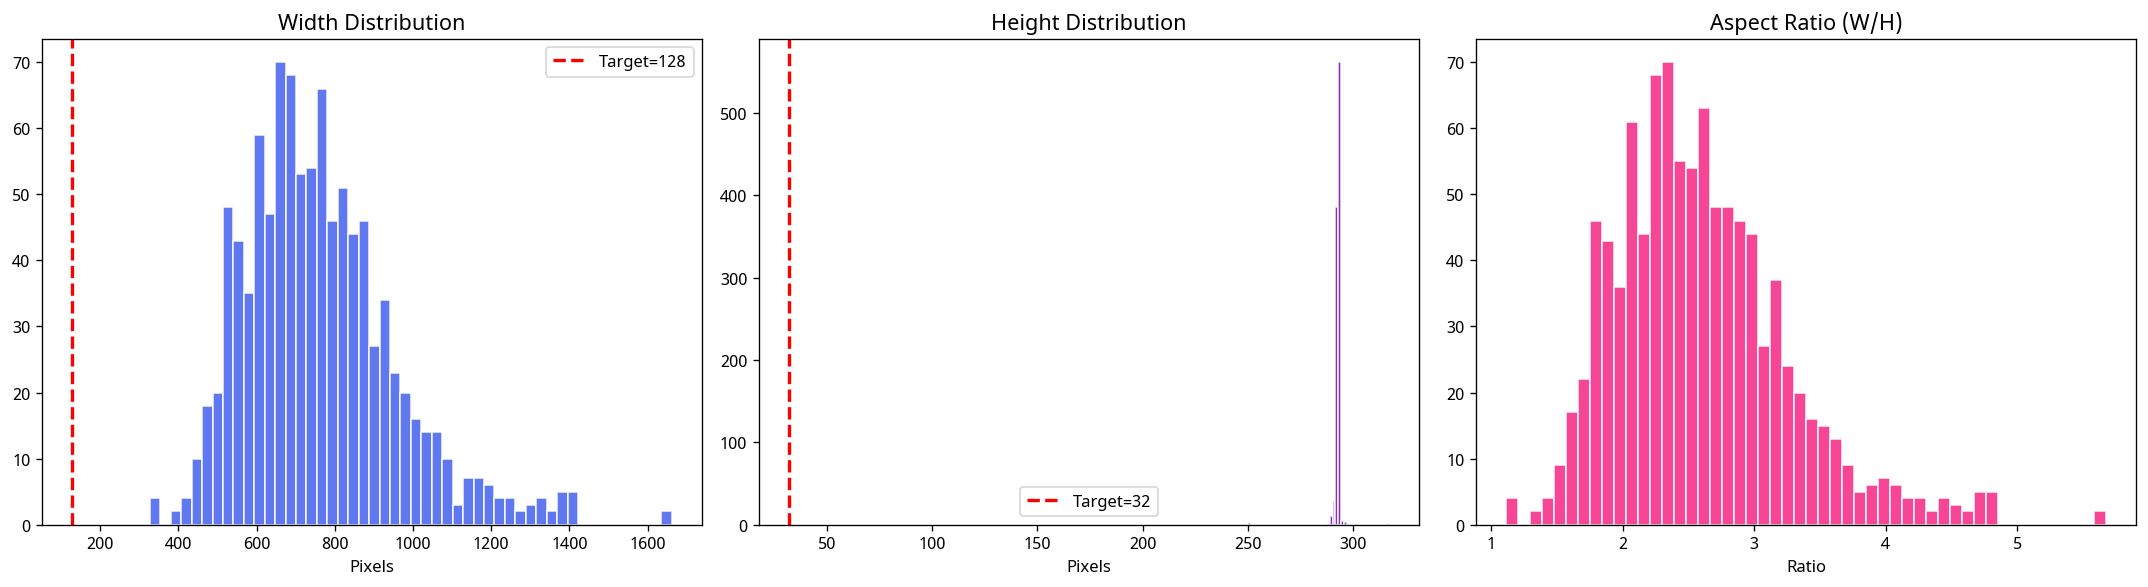

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(widths, bins=50, color='#4361ee', edgecolor='white', alpha=0.85)
axes[0].axvline(128, color='red', ls='--', lw=2, label='Target=128')
axes[0].set_title('Width Distribution', fontsize=13); axes[0].set_xlabel('Pixels'); axes[0].legend()

axes[1].hist(heights, bins=50, color='#7209b7', edgecolor='white', alpha=0.85)
axes[1].axvline(32, color='red', ls='--', lw=2, label='Target=32')
axes[1].set_title('Height Distribution', fontsize=13); axes[1].set_xlabel('Pixels'); axes[1].legend()

ratios = [w/max(h,1) for w,h in zip(widths, heights)]
axes[2].hist(ratios, bins=50, color='#f72585', edgecolor='white', alpha=0.85)
axes[2].set_title('Aspect Ratio (W/H)', fontsize=13); axes[2].set_xlabel('Ratio')

plt.tight_layout()
plt.savefig(RESULTS / 'image_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Label & Character Analysis

In [20]:
labels = train_df[LABEL_COL].astype(str).tolist()
print(f'Total labeled samples: {len(labels):,}')

# Word lengths
word_lens = [len(w) for w in labels]
print(f'Word length — min:{min(word_lens)}  max:{max(word_lens)}  mean:{np.mean(word_lens):.1f}  median:{np.median(word_lens):.0f}')

# Full character set
all_chars = ''.join(labels)
char_freq = Counter(all_chars)
vocab = sorted(char_freq.keys())

print(f'\nTotal characters: {len(all_chars):,}')
print(f'Unique characters (vocabulary size): {len(vocab)}')
print(f'CTC output classes needed: {len(vocab) + 1}  (vocab + blank)')

Total labeled samples: 69,853
Word length — min:1  max:23  mean:6.0  median:6

Total characters: 417,611
Unique characters (vocabulary size): 108
CTC output classes needed: 109  (vocab + blank)


In [21]:
# Unicode category breakdown
cat_names = {
    'Lo': 'Letter (Devanagari)',
    'Mn': 'Non-spacing mark (matra/nukta)',
    'Mc': 'Spacing mark (matra)',
    'Nd': 'Digit',
    'Po': 'Punctuation',
    'Zs': 'Space',
}
cats = Counter()
for ch in all_chars:
    c = unicodedata.category(ch)
    cats[cat_names.get(c, f'Other ({c})')] += 1

print('--- Unicode Category Breakdown ---')
for cat, count in cats.most_common():
    print(f'  {cat:<40} {count:>8,}  ({count/len(all_chars)*100:>5.1f}%)')

--- Unicode Category Breakdown ---
  Letter (Devanagari)                       251,571  ( 60.2%)
  Spacing mark (matra)                       83,381  ( 20.0%)
  Non-spacing mark (matra/nukta)             77,039  ( 18.4%)
  Punctuation                                 2,531  (  0.6%)
  Other (Pd)                                  2,407  (  0.6%)
  Digit                                         674  (  0.2%)
  Other (Lm)                                      8  (  0.0%)


In [22]:
# Top 25 most frequent characters
print('--- Top 25 Characters ---')
print(f'{"Char":<6} {"Unicode":<10} {"Name":<45} {"Count":>8}')
print('-' * 75)
for ch, cnt in char_freq.most_common(25):
    name = unicodedata.name(ch, '???')
    print(f"  {ch:<4}   U+{ord(ch):04X}     {name:<45} {cnt:>8,}")

--- Top 25 Characters ---
Char   Unicode    Name                                             Count
---------------------------------------------------------------------------
  ा      U+093E     DEVANAGARI VOWEL SIGN AA                        38,075
  र      U+0930     DEVANAGARI LETTER RA                            27,660
  ्      U+094D     DEVANAGARI SIGN VIRAMA                          26,771
  न      U+0928     DEVANAGARI LETTER NA                            17,642
  ि      U+093F     DEVANAGARI VOWEL SIGN I                         17,586
  क      U+0915     DEVANAGARI LETTER KA                            16,794
  े      U+0947     DEVANAGARI VOWEL SIGN E                         15,883
  स      U+0938     DEVANAGARI LETTER SA                            15,431
  त      U+0924     DEVANAGARI LETTER TA                            15,361
  ं      U+0902     DEVANAGARI SIGN ANUSVARA                        15,141
  ी      U+0940     DEVANAGARI VOWEL SIGN II                        14,701


In [23]:
# Save vocabulary mapping (0 = CTC blank)
char_to_idx = {ch: i + 1 for i, ch in enumerate(vocab)}
idx_to_char = {i + 1: ch for i, ch in enumerate(vocab)}
idx_to_char[0] = '<BLANK>'

vocab_info = {
    'vocab_size': len(vocab),
    'num_classes': len(vocab) + 1,
    'char_to_idx': char_to_idx,
    'idx_to_char': {str(k): v for k, v in idx_to_char.items()},
    'avg_word_length': float(np.mean(word_lens)),
    'max_word_length': max(word_lens),
}

with open(RESULTS / 'vocab.json', 'w', encoding='utf-8') as f:
    json.dump(vocab_info, f, ensure_ascii=False, indent=2)

print(f'Vocabulary saved to results/vocab.json')
print(f'  Vocab size: {len(vocab)}')
print(f'  Num classes (with CTC blank): {len(vocab)+1}')

Vocabulary saved to results/vocab.json
  Vocab size: 108
  Num classes (with CTC blank): 109


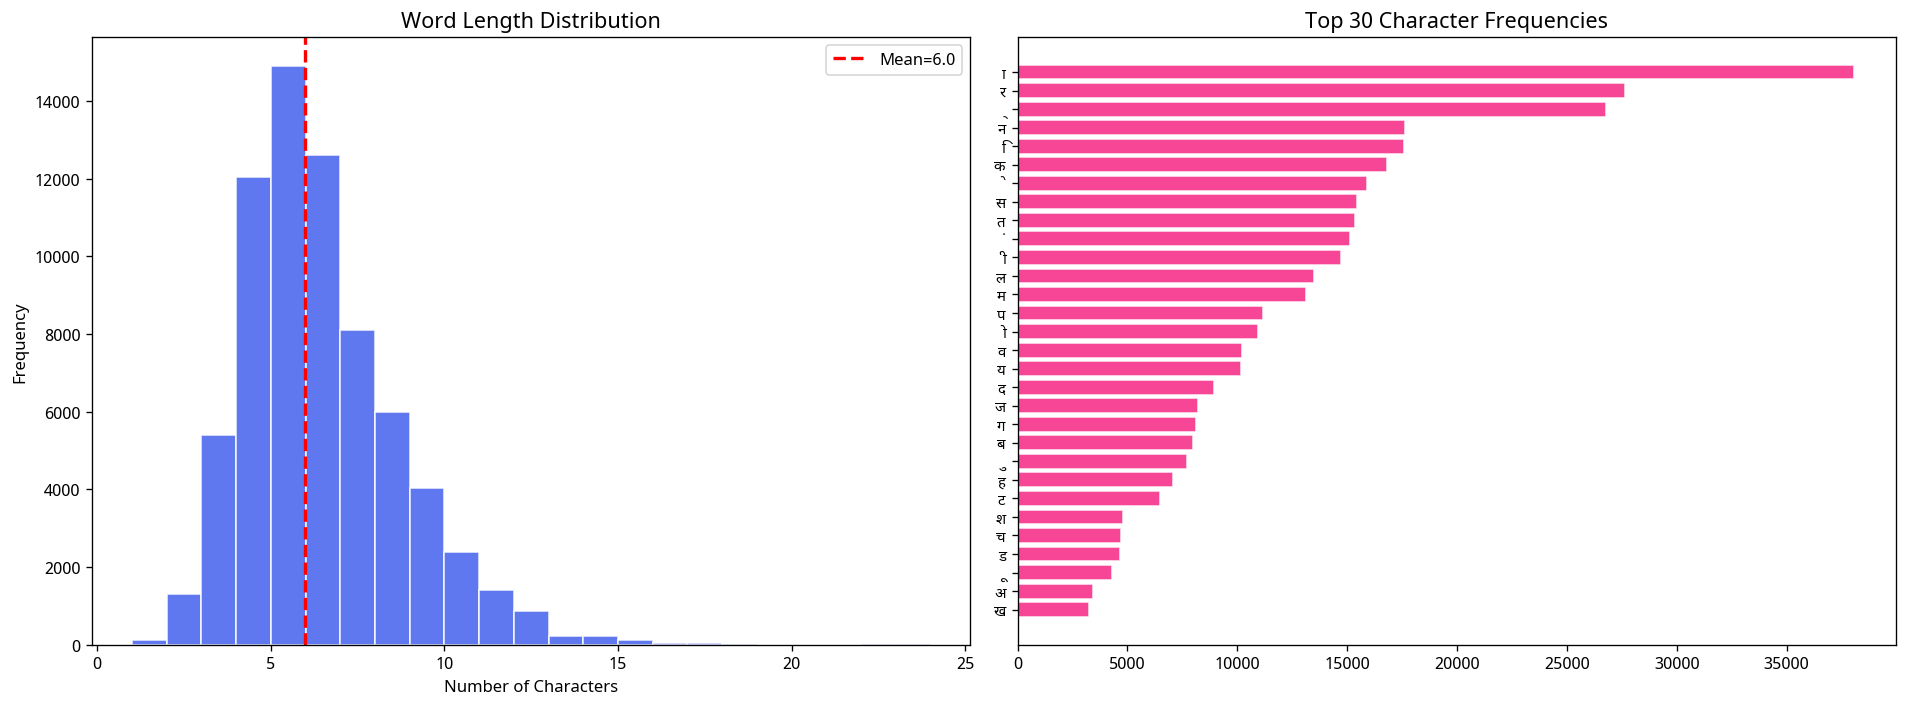

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(word_lens, bins=range(1, max(word_lens)+2), color='#4361ee', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(word_lens), color='red', ls='--', lw=2, label=f'Mean={np.mean(word_lens):.1f}')
axes[0].set_title('Word Length Distribution', fontsize=13)
axes[0].set_xlabel('Number of Characters'); axes[0].set_ylabel('Frequency'); axes[0].legend()

top30 = char_freq.most_common(30)
axes[1].barh(range(30), [c[1] for c in top30], color='#f72585', edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(30))
axes[1].set_yticklabels([c[0] for c in top30], fontsize=9)
axes[1].set_title('Top 30 Character Frequencies', fontsize=13)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(RESULTS / 'label_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Preprocessing Preview
Preview what images will look like after resize to 32x128 (CRNN input size).

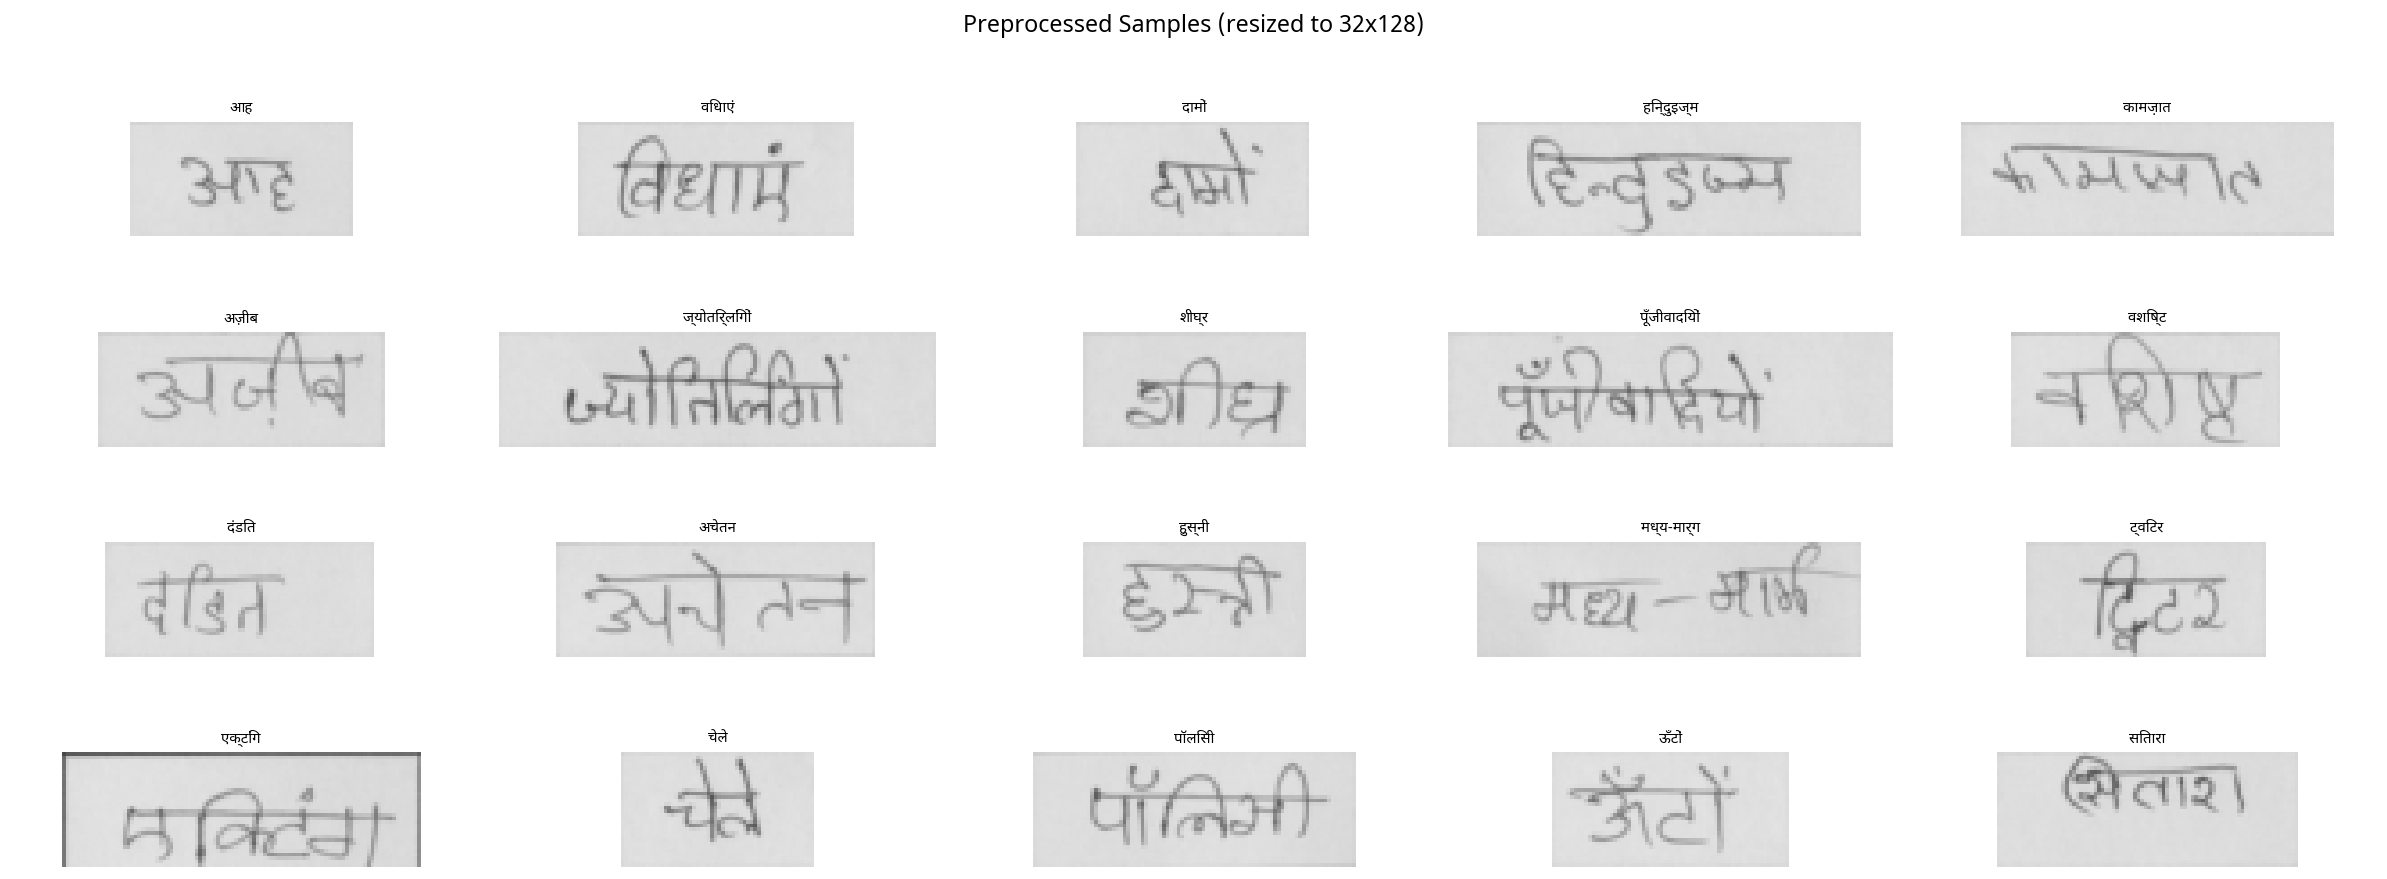

In [25]:
TARGET_H, TARGET_W = 32, 128

def preprocess_preview(row):
    """Show what the CRNN will see: grayscale, resized, normalized."""
    img = row_to_image(row).convert('L')
    # Resize maintaining aspect ratio, pad to target
    w, h = img.size
    ratio = min(TARGET_W / w, TARGET_H / h)
    new_w, new_h = int(w * ratio), int(h * ratio)
    img_resized = img.resize((new_w, new_h), Image.BILINEAR)
    # Pad to target size (white background)
    padded = Image.new('L', (TARGET_W, TARGET_H), 255)
    paste_x = (TARGET_W - new_w) // 2
    paste_y = (TARGET_H - new_h) // 2
    padded.paste(img_resized, (paste_x, paste_y))
    return padded

fig, axes = plt.subplots(4, 5, figsize=(20, 8))
fig.suptitle(f'Preprocessed Samples (resized to {TARGET_H}x{TARGET_W})', fontsize=14, fontweight='bold')

np.random.seed(123)
idx = np.random.choice(len(train_df), 20, replace=False)
for i, ax in enumerate(axes.flat):
    row = train_df.iloc[idx[i]]
    try:
        processed = preprocess_preview(row)
        ax.imshow(np.array(processed), cmap='gray', vmin=0, vmax=255)
    except Exception as e:
        ax.text(0.5, 0.5, str(e)[:30], ha='center', fontsize=7)
    ax.set_title(str(row[LABEL_COL]), fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS / 'preprocessed_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. EasyOCR Baseline

In [26]:
import easyocr
import editdistance

reader = easyocr.Reader(['hi'], gpu=True)  
print('EasyOCR loaded (Hindi)')

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR loaded (Hindi)


In [27]:
# Run baseline on 200 random test samples
eval_df = test_df if len(test_df) > 0 else val_df
np.random.seed(42)
n_eval = min(200, len(eval_df))
eval_idx = np.random.choice(len(eval_df), n_eval, replace=False)

results = []
for i, idx in enumerate(eval_idx):
    row = eval_df.iloc[idx]
    gt = str(row[LABEL_COL])
    
    try:
        img = row_to_image(row)
        img_rgb = np.array(img.convert('RGB'))
        pred_list = reader.readtext(img_rgb, detail=0)
        pred = ''.join(pred_list).strip()
    except Exception:
        pred = ''
    
    cer = editdistance.eval(pred, gt) / max(len(gt), 1)
    results.append({'ground_truth': gt, 'predicted': pred, 'exact_match': pred == gt, 'cer': cer})
    
    if (i + 1) % 50 == 0:
        running_acc = sum(r['exact_match'] for r in results) / len(results) * 100
        running_cer = np.mean([r['cer'] for r in results])
        print(f'  [{i+1}/{n_eval}] Accuracy: {running_acc:.1f}%  CER: {running_cer:.3f}')

res_df = pd.DataFrame(results)
print(f'\n{"="*50}')
print(f'  EasyOCR Baseline Results ({n_eval} samples)')
print(f'{"="*50}')
print(f'  Exact match accuracy: {res_df["exact_match"].mean()*100:.1f}%')
print(f'  Average CER:          {res_df["cer"].mean():.4f} ({res_df["cer"].mean()*100:.1f}%)')
print(f'  Median CER:           {res_df["cer"].median():.4f}')
print(f'{"="*50}')

res_df.to_csv(RESULTS / 'easyocr_baseline.csv', index=False)
print(f'Results saved to results/easyocr_baseline.csv')

  [50/200] Accuracy: 0.0%  CER: 0.767
  [100/200] Accuracy: 0.0%  CER: 0.779
  [150/200] Accuracy: 0.0%  CER: 0.788
  [200/200] Accuracy: 0.0%  CER: 0.805

  EasyOCR Baseline Results (200 samples)
  Exact match accuracy: 0.0%
  Average CER:          0.8051 (80.5%)
  Median CER:           0.8333
Results saved to results/easyocr_baseline.csv


In [28]:
# Show sample predictions
print(f'{"Ground Truth":<25} {"Predicted":<25} {"CER":<8} Match')
print('-' * 70)
for _, r in res_df.head(20).iterrows():
    icon = 'YES' if r['exact_match'] else '  X'
    print(f'{r["ground_truth"]:<25} {r["predicted"]:<25} {r["cer"]:.3f}    {icon}')

Ground Truth              Predicted                 CER      Match
----------------------------------------------------------------------
सुलझा                     4ना                       0.800      X
आराजकता                   २1रज॰ 7                   0.857      X
ट्यूब                     ८व                        1.000      X
अनशन                      ३^शन                      0.500      X
बलदेवनगर                  क़लदवभ द१२                 0.875      X
पैन                                                 1.000      X
पद्धति                    फ५                        1.000      X
जाड़ों                     ज१ा<                      0.800      X
लच्छेदार-आलंकारिक         लच्ददा२ आल्ू              0.588      X
स्टानफोर्ड                २ट^फ)                     0.800      X
जाल                       ट                         1.000      X
तान्त्रिक                 तान्त्रि                  0.111      X
बॉक्स                     ृ/ठ२                      1.000      X
बताओ             

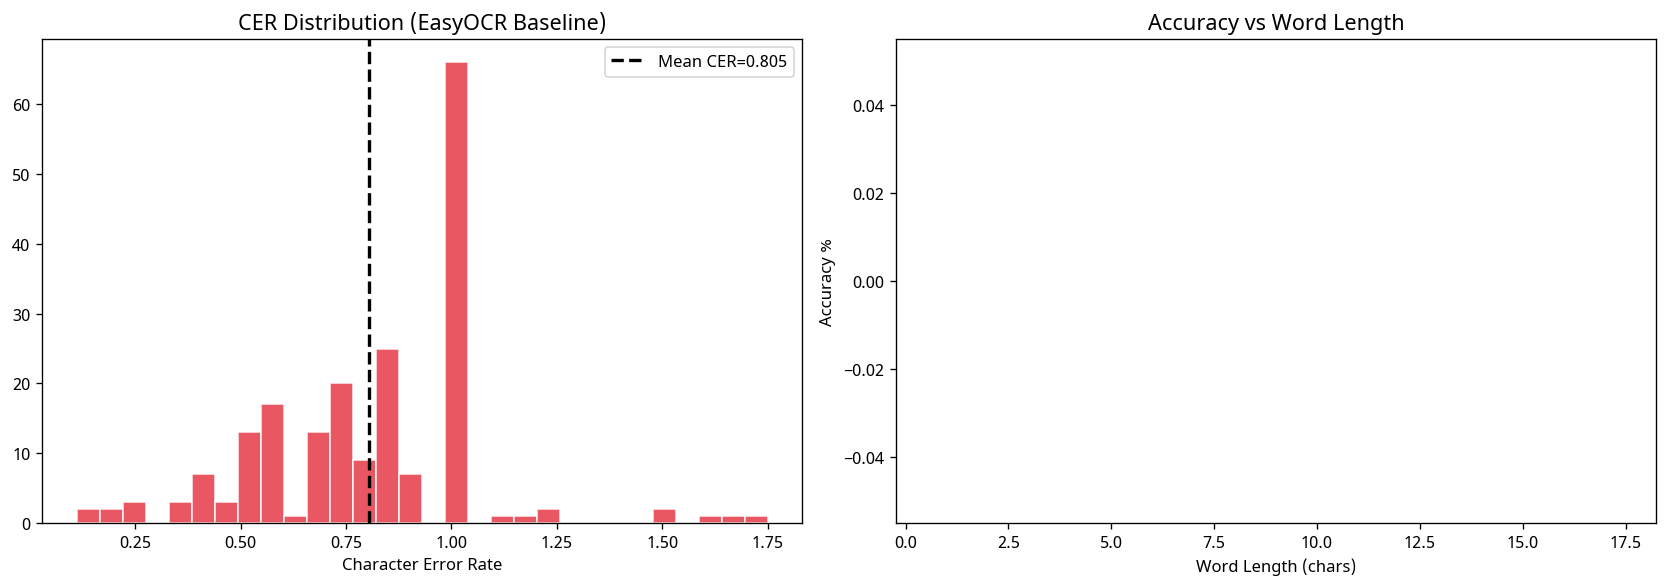

In [29]:
# CER distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(res_df['cer'], bins=30, color='#e63946', edgecolor='white', alpha=0.85)
axes[0].axvline(res_df['cer'].mean(), color='black', ls='--', lw=2, label=f'Mean CER={res_df["cer"].mean():.3f}')
axes[0].set_title('CER Distribution (EasyOCR Baseline)', fontsize=13)
axes[0].set_xlabel('Character Error Rate'); axes[0].legend()

# Accuracy by word length
res_df['gt_len'] = res_df['ground_truth'].str.len()
len_acc = res_df.groupby('gt_len')['exact_match'].mean() * 100
axes[1].bar(len_acc.index, len_acc.values, color='#457b9d', edgecolor='white', alpha=0.85)
axes[1].set_title('Accuracy vs Word Length', fontsize=13)
axes[1].set_xlabel('Word Length (chars)'); axes[1].set_ylabel('Accuracy %')

plt.tight_layout()
plt.savefig(RESULTS / 'baseline_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary Report

In [30]:
print('=' * 60)
print('  PHASE 1 SUMMARY')
print('=' * 60)
print(f'''
DATASET
  Train samples:     {len(train_df):,}
  Val samples:       {len(val_df):,}
  Test samples:      {len(test_df):,}
  Image column:      {IMG_COL}
  Label column:      {LABEL_COL}

IMAGES
  Width range:       {min(widths)} - {max(widths)} px  (target: 128)
  Height range:      {min(heights)} - {max(heights)} px  (target: 32)

VOCABULARY
  Unique chars:      {len(vocab)}
  CTC classes:       {len(vocab) + 1}  (vocab + blank)
  Avg word length:   {np.mean(word_lens):.1f} chars
  Max word length:   {max(word_lens)} chars

EASYOCR BASELINE
  Exact match acc:   {res_df["exact_match"].mean()*100:.1f}%
  Average CER:       {res_df["cer"].mean():.4f}

NEXT STEPS (Phase 2)
  1. Build preprocessing pipeline (resize, normalize)
  2. Create PyTorch Dataset + DataLoader
  3. Implement data augmentation
  4. Define CRNN architecture
''')

  PHASE 1 SUMMARY

DATASET
  Train samples:     69,853
  Val samples:       12,708
  Test samples:      12,869
  Image column:      image
  Label column:      text

IMAGES
  Width range:       327 - 1662 px  (target: 128)
  Height range:      250 - 317 px  (target: 32)

VOCABULARY
  Unique chars:      108
  CTC classes:       109  (vocab + blank)
  Avg word length:   6.0 chars
  Max word length:   23 chars

EASYOCR BASELINE
  Exact match acc:   0.0%
  Average CER:       0.8051

NEXT STEPS (Phase 2)
  1. Build preprocessing pipeline (resize, normalize)
  2. Create PyTorch Dataset + DataLoader
  3. Implement data augmentation
  4. Define CRNN architecture

